# Evaluating Methods for Choosing K in K-Means Clustering

## Research Question
How can we determine the optimal number of clusters (K) in K-Means clustering, and how reliable are the Elbow method and Silhouette score across different types of datasets?

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Introduction

Clustering is an unsupervised machine learning technique used to group similar data points without predefined labels. One of the most widely used clustering algorithms is K-Means, which partitions data into K clusters by minimising the distance between data points and their cluster centroids.

A key challenge in K-Means is selecting the appropriate number of clusters (K), as this directly affects the quality of the clustering. In this notebook, we explore two common methods for choosing K: the Elbow method and the Silhouette score, and evaluate their effectiveness on different types of datasets.

## Dataset Selection

To evaluate the behaviour of K-Means and methods for choosing K, three datasets are used:

- **Well-separated clusters**: Ideal case where clusters are clearly distinct
- **Overlapping clusters**: More challenging case with unclear boundaries
- **Non-spherical clusters**: Complex shapes where K-Means assumptions break down

These datasets allow us to analyse how clustering performance changes under different conditions.

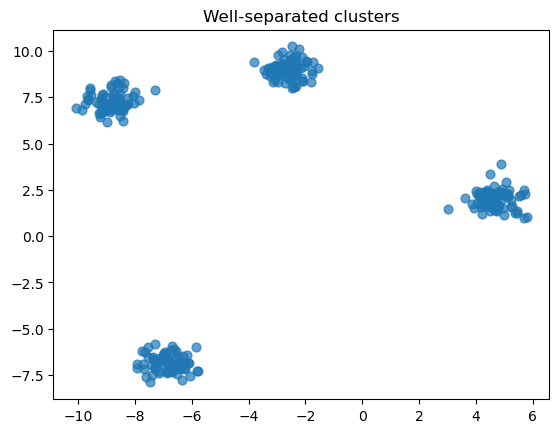

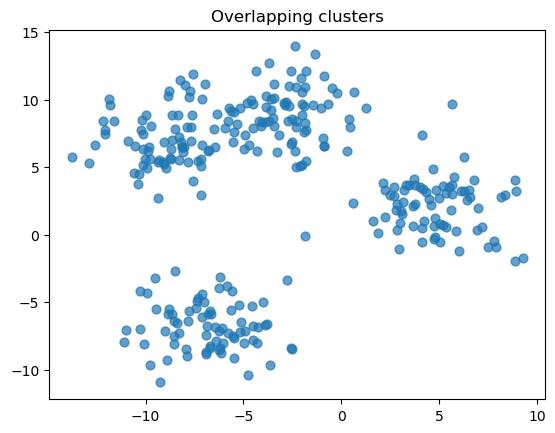

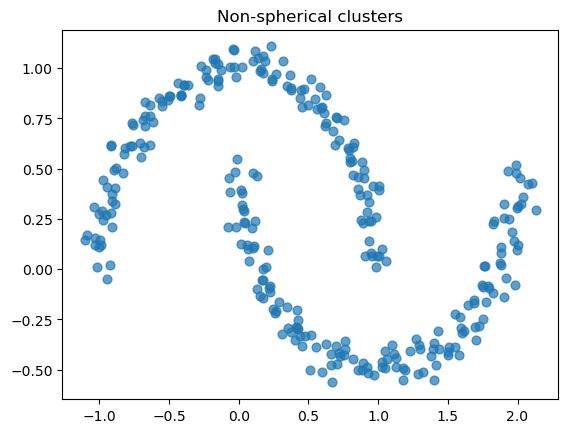

In [13]:
# Dataset 1: Well-separated clusters
X1, y1 = make_blobs(n_samples=300, centers=4, cluster_std=0.5, random_state=42)

# Dataset 2: Overlapping clusters
X2, y2 = make_blobs(n_samples=300, centers=4, cluster_std=2.0, random_state=42)

# Dataset 3: Non-spherical clusters

X3, y3 = make_moons(n_samples=300, noise=0.05, random_state=42)


# Function to plot dataset
def plot_data(X, title, filename):
    plt.figure()  # Create a new figure for each plot
    plt.scatter(X[:, 0], X[:, 1], s=40, alpha=0.7)
    plt.title(title)
    plt.savefig(filename, bbox_inches='tight', dpi=300)  # Save properly
    plt.show()

plot_data(X1, "Well-separated clusters", "clusters_well_separated.png")
plot_data(X2, "Overlapping clusters", "clusters_overlapping.png")
plot_data(X3, "Non-spherical clusters", "clusters_nonspherical.png")

## Applying K-Means Clustering

K-Means clustering is applied to each dataset using an appropriate value of K. The goal is to observe how well the algorithm identifies clusters under different data conditions.

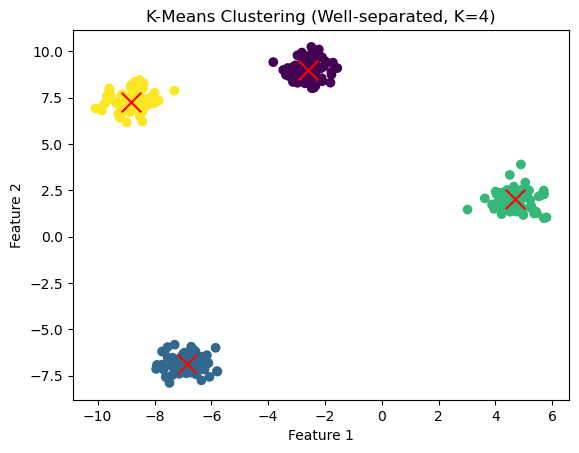

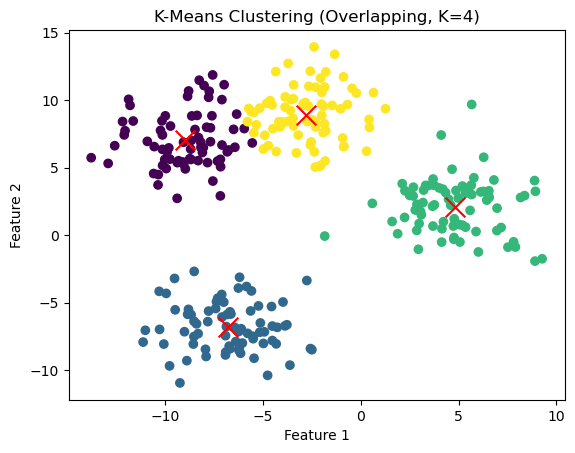

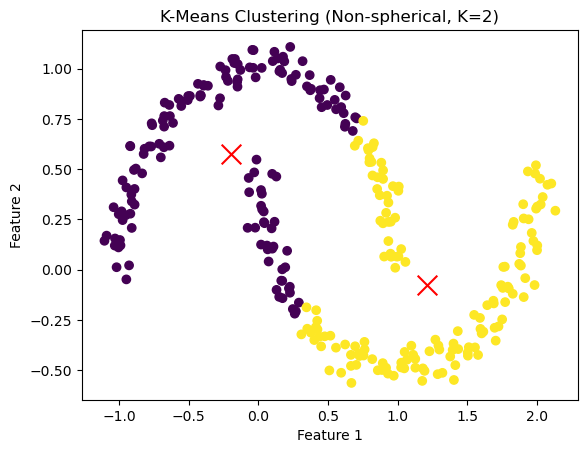

In [14]:
# Applying KMeans to all 3 datasets
datasets = [
    (X1, "Well-separated", 4),
    (X2, "Overlapping", 4),
    (X3, "Non-spherical", 2)
]

for X, name, k in datasets:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
    plt.scatter(kmeans.cluster_centers_[:, 0],
                kmeans.cluster_centers_[:, 1],
                marker='x', s=200, c='red')
    
    plt.title(f"K-Means Clustering ({name}, K={k})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    filename = f"kmeans_{name.lower().replace(' ', '_')}.png"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

## Evaluating the Choice of K

To determine the optimal number of clusters, two methods are used:

- **Elbow Method**: Measures the Within-Cluster Sum of Squares (WCSS)
- **Silhouette Score**: Evaluates how well-separated the clusters are

These methods are applied across a range of K values to analyse their effectiveness.

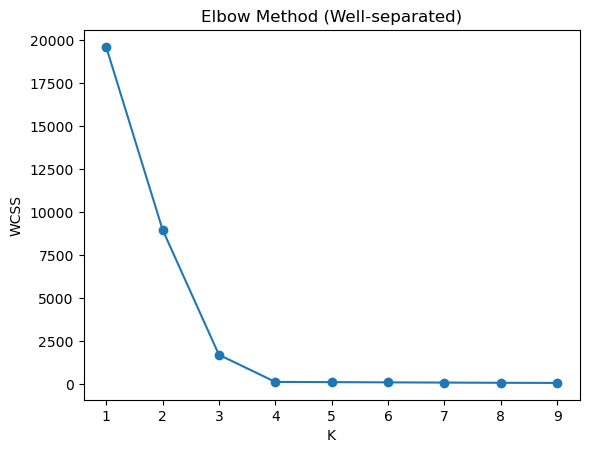

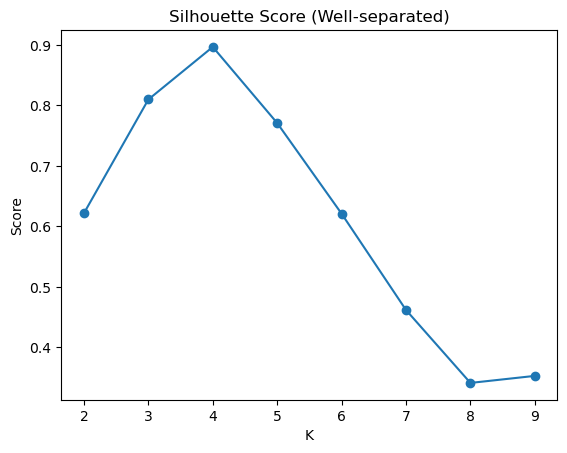

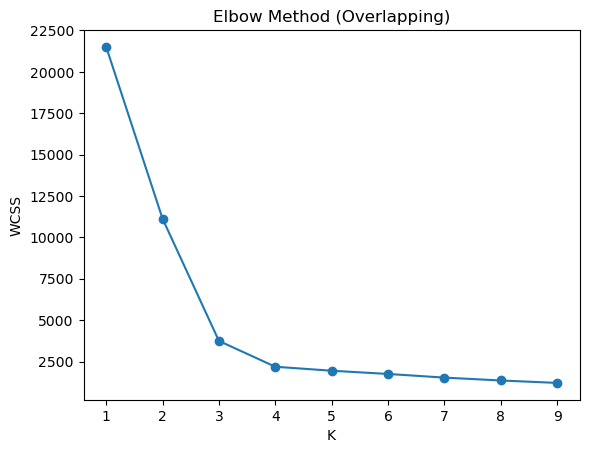

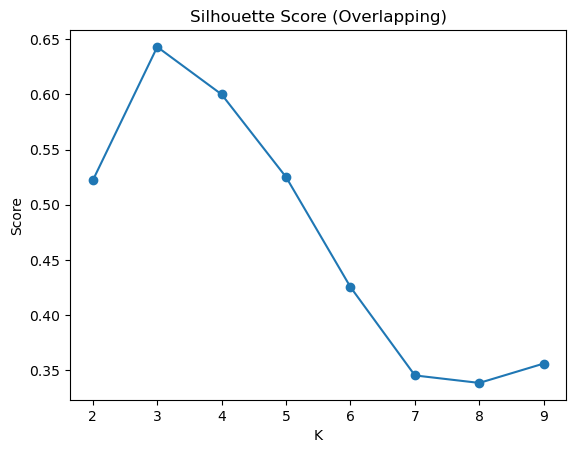

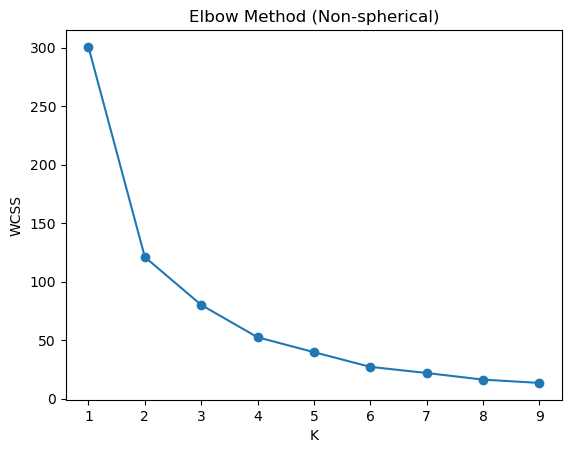

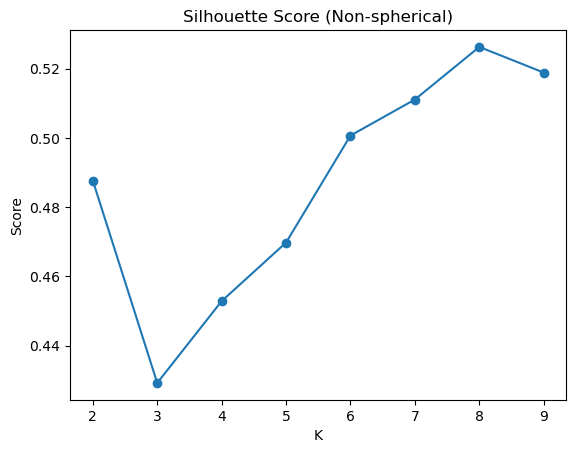

In [15]:
def evaluate_kmeans(X, k_range):
    wcss = []
    silhouette_scores = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)

        wcss.append(kmeans.inertia_)

        if k > 1:
            score = silhouette_score(X, labels)
            silhouette_scores.append(score)
        else:
            silhouette_scores.append(None)

    return wcss, silhouette_scores


def plot_results(k_range, wcss, silhouette_scores, title):
    
    #File name when saving the figures
    base_name = title.lower().replace(' ', '_')

    # Elbow Plot
    plt.figure()
    plt.plot(k_range, wcss, marker='o')
    plt.title(f"Elbow Method ({title})")
    plt.xlabel("K")
    plt.ylabel("WCSS")
    
    plt.savefig(f"elbow_{base_name}.png", bbox_inches='tight', dpi=300)
    plt.show()

    #Silhouette Plot
    plt.figure()
    plt.plot(k_range[1:], silhouette_scores[1:], marker='o')
    plt.title(f"Silhouette Score ({title})")
    plt.xlabel("K")
    plt.ylabel("Score")
    
    plt.savefig(f"silhouette_{base_name}.png", bbox_inches='tight', dpi=300)
    plt.show()


k_range = range(1, 10)

for X, name in [(X1, "Well-separated"),
                (X2, "Overlapping"),
                (X3, "Non-spherical")]:
    
    wcss, sil = evaluate_kmeans(X, k_range)
    plot_results(k_range, wcss, sil, name)

## Observations and Insights

- In the well-separated dataset, both Elbow and Silhouette methods clearly indicate the correct number of clusters.
- In the overlapping dataset, the Elbow method becomes less clear, while the Silhouette score provides better guidance.
- In the non-spherical dataset, both methods struggle, highlighting the limitations of K-Means.

These results show that the effectiveness of methods for choosing K depends heavily on the structure of the data.